# Lab 13: Memorias asociativas con redes de Hopfield

Una red de Hopfield es una red recurrente que puede almacenar patrones binarios y recuperarlos
cuando se le presenta una versión corrupta o incompleta. Es uno de los primeros modelos de memoria
asociativa basada en redes neuronales.

La idea es que la red evoluciona hacia un mínimo de energía que corresponde al patrón almacenado
más cercano al estado inicial.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Funciones auxiliares del modelo

Implementamos cada función por separado, como pide el enunciado:
conversión de imagen a vector, cálculo de pesos, campo local, actualización, energía, ruido y recuperación.

In [2]:
# Punto 1: convertir imagen binaria en vector de estados {-1, +1}
def imagen_a_vector(img):
    """
    Convierte una imagen binaria (n, m) en un vector de estados plano.
    Los valores 1 se mantienen, los 0 se convierten a -1.
    """
    return img.flatten().astype(float)


# Punto 2: calcular la matriz de pesos usando la regla de Hebb
def calcular_pesos(patrones):
    """
    patrones: lista de vectores de estados xi de longitud N.
    Devuelve W de forma (N, N) con diagonal nula.

    w_ij = (1/N) * sum_mu(xi_i^mu * xi_j^mu)  con w_ii = 0
    """
    N = len(patrones[0])
    P = len(patrones)
    W = np.zeros((N, N))

    for xi in patrones:
        W += np.outer(xi, xi)

    W /= N
    np.fill_diagonal(W, 0)  # w_ii = 0, sin auto-conexiones
    return W


# Punto 3: campo local sobre la neurona i
def campo_local(W, s, i):
    """h_i = sum_j w_ij * s_j"""
    return W[i].dot(s)


# Punto 4: actualizar el estado de una neurona
def actualizar_neurona(W, s, i):
    """s_i <- sign(h_i), con sign(0) = -1 por convención."""
    h = campo_local(W, s, i)
    return 1 if h > 0 else -1


# Punto 5: energía total de la red
def energia(W, s):
    """E = -0.5 * s^T W s"""
    return -0.5 * s.dot(W.dot(s))


# Punto 6: agregar ruido a una imagen
def agregar_ruido(patron, fraccion_ruido=0.2, seed=None):
    """
    Invierte aleatoriamente una fracción de los bits del patrón.
    """
    rng = np.random.default_rng(seed)
    patron_ruidoso = patron.copy()
    N = len(patron)
    n_flips = int(fraccion_ruido * N)
    indices = rng.choice(N, size=n_flips, replace=False)
    patron_ruidoso[indices] *= -1
    return patron_ruidoso


# Punto 7: recuperación mediante actualización asíncrona aleatoria
def recuperar(W, estado_inicial, n_iter=20, seed=None):
    """
    Actualiza las neuronas en orden aleatorio hasta convergencia o n_iter pasos.
    Devuelve el estado final y el historial de energía.
    """
    rng = np.random.default_rng(seed)
    s = estado_inicial.copy()
    N = len(s)
    hist_energia = [energia(W, s)]

    for _ in range(n_iter):
        orden = rng.permutation(N)
        s_prev = s.copy()

        for i in orden:
            s[i] = actualizar_neurona(W, s, i)

        hist_energia.append(energia(W, s))

        # Criterio de parada: el estado no cambió
        if np.array_equal(s, s_prev):
            break

    return s, hist_energia

## 2. Patrones a almacenar

Usamos los tres patrones del enunciado (horizontal, vertical y tablero de ajedrez) sobre una grilla de 8x8.
Todos los valores son $\pm 1$ para que la regla de Hebb funcione correctamente.

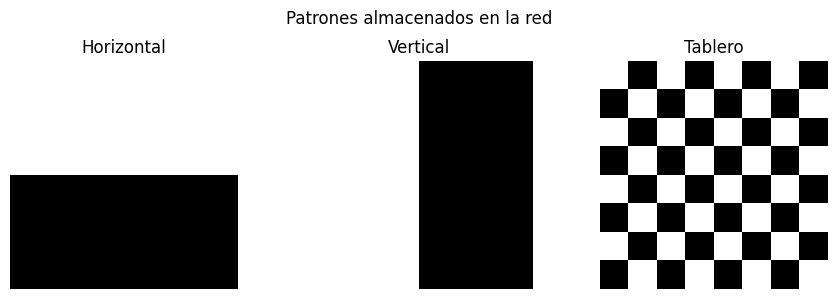

In [3]:
def patrones_balanceados(n, m):
    horizontal = -np.ones((n, m))
    horizontal[:n//2, :] = 1

    vertical = -np.ones((n, m))
    vertical[:, :m//2] = 1

    checker = np.indices((n, m)).sum(axis=0)
    checker = np.where(checker % 2 == 0, 1, -1)

    return horizontal, vertical, checker


n, m = 8, 8
horizontal, vertical, checker = patrones_balanceados(n, m)
patrones_img = [horizontal, vertical, checker]
nombres = ['Horizontal', 'Vertical', 'Tablero']

# Visualizamos los patrones originales
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, img, nombre in zip(axes, patrones_img, nombres):
    ax.imshow(img, cmap='gray', vmin=-1, vmax=1)
    ax.set_title(nombre)
    ax.axis('off')
plt.suptitle('Patrones almacenados en la red')
plt.tight_layout()
plt.show()

## 3. Entrenamiento: cálculo de la matriz de pesos

Aplicamos la regla de Hebb. El resultado es una matriz simétrica con diagonal nula.
La capacidad de la red es aproximadamente $0.14 \cdot N$ patrones para una red de $N$ neuronas
(con $N = 64$ podríamos almacenar unos 9 patrones antes de interferencias serias).

Dimensión de W: (64, 64)
Diagonal de W (debe ser todo ceros): [0. 0. 0. 0. 0.] ...
W es simétrica: True
Rango de valores en W: [-0.0469, 0.0469]


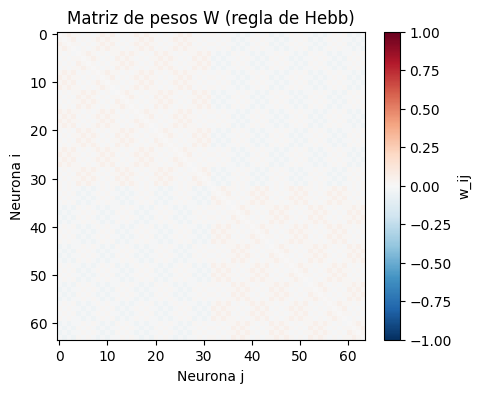

In [4]:
# Convertimos las imágenes a vectores
vectores = [imagen_a_vector(img) for img in patrones_img]

# Calculamos la matriz de pesos
W = calcular_pesos(vectores)

print(f'Dimensión de W: {W.shape}')
print(f'Diagonal de W (debe ser todo ceros): {np.diag(W)[:5]} ...')
print(f'W es simétrica: {np.allclose(W, W.T)}')
print(f'Rango de valores en W: [{W.min():.4f}, {W.max():.4f}]')

plt.figure(figsize=(5, 4))
plt.imshow(W, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='w_ij')
plt.title('Matriz de pesos W (regla de Hebb)')
plt.xlabel('Neurona j')
plt.ylabel('Neurona i')
plt.show()

## 4. Recuperación de patrones con ruido

Tomamos cada patrón, le agregamos ruido (invertimos el 20-30% de los bits)
y vemos si la red lo recupera.

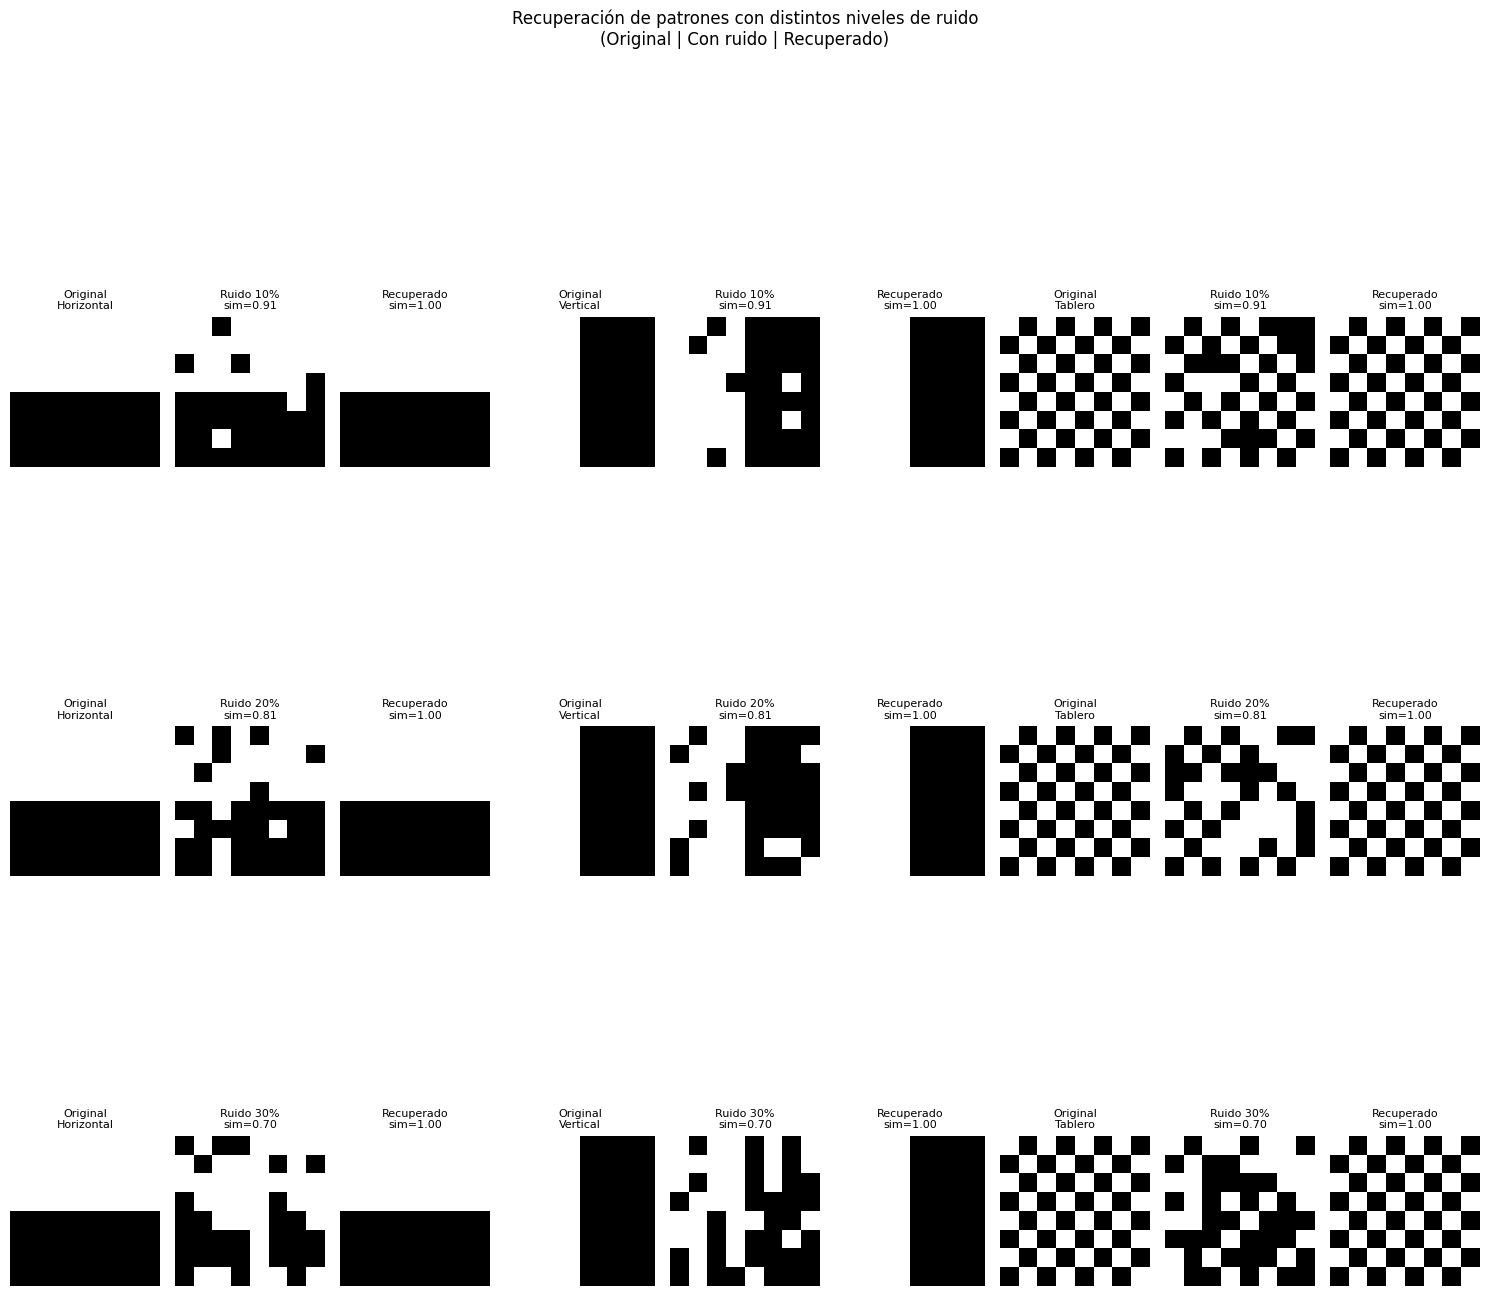

In [5]:
def similitud(a, b):
    """Fracción de bits que coinciden entre dos vectores de estados."""
    return np.mean(a == b)


fracciones_ruido = [0.1, 0.2, 0.3]

fig, axes = plt.subplots(len(fracciones_ruido), len(patrones_img) * 3,
                          figsize=(15, 5 * len(fracciones_ruido)))

for fila, fr in enumerate(fracciones_ruido):
    for col, (xi, img, nombre) in enumerate(zip(vectores, patrones_img, nombres)):
        xi_ruidoso = agregar_ruido(xi, fraccion_ruido=fr, seed=col)
        xi_recuperado, hist_e = recuperar(W, xi_ruidoso, n_iter=50, seed=col)

        sim_entrada = similitud(xi, xi_ruidoso)
        sim_salida  = similitud(xi, xi_recuperado)

        base = col * 3

        # Original
        axes[fila, base].imshow(img, cmap='gray', vmin=-1, vmax=1)
        axes[fila, base].set_title(f'Original\n{nombre}', fontsize=8)
        axes[fila, base].axis('off')

        # Con ruido
        axes[fila, base+1].imshow(xi_ruidoso.reshape(n, m), cmap='gray', vmin=-1, vmax=1)
        axes[fila, base+1].set_title(f'Ruido {int(fr*100)}%\nsim={sim_entrada:.2f}', fontsize=8)
        axes[fila, base+1].axis('off')

        # Recuperado
        axes[fila, base+2].imshow(xi_recuperado.reshape(n, m), cmap='gray', vmin=-1, vmax=1)
        axes[fila, base+2].set_title(f'Recuperado\nsim={sim_salida:.2f}', fontsize=8)
        axes[fila, base+2].axis('off')

plt.suptitle('Recuperación de patrones con distintos niveles de ruido\n(Original | Con ruido | Recuperado)', y=1.01)
plt.tight_layout()
plt.show()

## 5. Evolución de la energía durante la recuperación

La energía de la red debe decrecer monótonamente durante la actualización asíncrona.
Esto garantiza que el proceso siempre converge a un mínimo (que esperamos sea el patrón almacenado
más cercano al estado inicial).

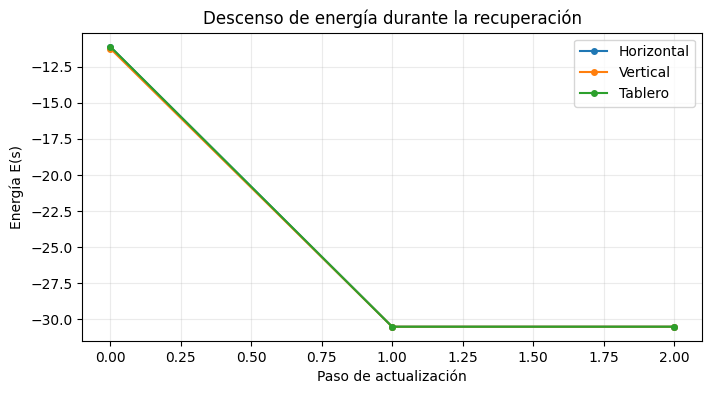

La energía siempre decrece (o se mantiene), nunca aumenta en actualización asíncrona.
La convergencia ocurre cuando el estado deja de cambiar entre iteraciones.


In [6]:
plt.figure(figsize=(8, 4))

for xi, nombre in zip(vectores, nombres):
    xi_ruidoso = agregar_ruido(xi, fraccion_ruido=0.2, seed=0)
    _, hist_e = recuperar(W, xi_ruidoso, n_iter=30, seed=0)
    plt.plot(hist_e, marker='o', markersize=4, label=nombre)

plt.xlabel('Paso de actualización')
plt.ylabel('Energía E(s)')
plt.title('Descenso de energía durante la recuperación')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print('La energía siempre decrece (o se mantiene), nunca aumenta en actualización asíncrona.')
print('La convergencia ocurre cuando el estado deja de cambiar entre iteraciones.')

## 6. Capacidad de la red: ¿cuántos patrones puede almacenar?

La capacidad máxima teórica es $C \approx 0.14 \cdot N$. Con $N=64$ eso son unos 9 patrones.
Al superarla, los patrones empiezan a interferir entre sí y la recuperación falla.

N=64 neuronas -> capacidad teórica ≈ 8 patrones


,P,tasa_recuperacion
0,1,1.00
1,2,1.00
2,3,1.00
3,4,1.00
4,5,1.00
5,6,1.00
6,7,1.00
7,8,0.88
8,9,0.89
9,10,0.90


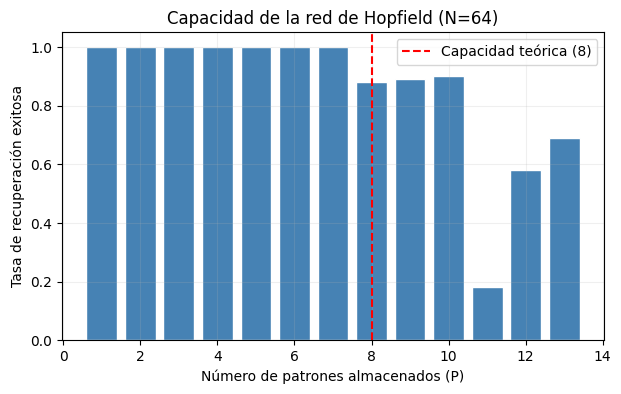

Pasado el límite teórico, la tasa de recuperación cae porque los patrones se solapan en el espacio de pesos.


In [7]:
import pandas as pd

np.random.seed(99)

n_prueba = 8
N = n_prueba * n_prueba
capacidad_teorica = int(0.14 * N)
print(f'N={N} neuronas -> capacidad teórica ≈ {capacidad_teorica} patrones')

resultados_cap = []

for P in range(1, 14):
    # Generamos P patrones aleatorios con valores en {-1, +1}
    pats = [np.random.choice([-1, 1], size=N) for _ in range(P)]
    W_cap = calcular_pesos(pats)

    # Intentamos recuperar cada patrón con 20% de ruido
    correctos = 0
    for xi in pats:
        xi_r = agregar_ruido(xi, fraccion_ruido=0.2, seed=0)
        xi_rec, _ = recuperar(W_cap, xi_r, n_iter=50, seed=0)
        if similitud(xi, xi_rec) > 0.9:
            correctos += 1

    tasa = correctos / P
    resultados_cap.append({'P': P, 'tasa_recuperacion': round(tasa, 2)})

df_cap = pd.DataFrame(resultados_cap)
display(df_cap)

plt.figure(figsize=(7, 4))
plt.bar(df_cap['P'], df_cap['tasa_recuperacion'], color='steelblue', edgecolor='white')
plt.axvline(capacidad_teorica, color='red', linestyle='--', label=f'Capacidad teórica ({capacidad_teorica})')
plt.xlabel('Número de patrones almacenados (P)')
plt.ylabel('Tasa de recuperación exitosa')
plt.title('Capacidad de la red de Hopfield (N=64)')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print('Pasado el límite teórico, la tasa de recuperación cae porque los patrones se solapan en el espacio de pesos.')

## 7. Aplicación con imagen real: `data.camera()`

El enunciado propone probar la red también con una imagen fotográfica real.
Cargamos `data.camera()` de scikit-image (512×512 píxeles en escala de grises),
la reducimos a 32×32 (N=1024 neuronas) para que sea manejable como red de Hopfield,
y la binarizamos a {-1, +1} con umbral en 0.5.

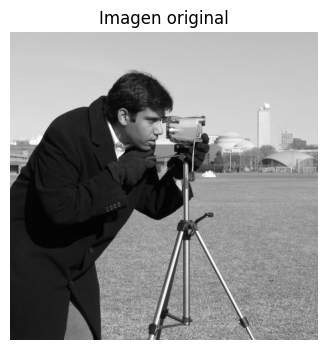

N = 1024 neuronas
W_cam: (1024, 1024), simétrica: True


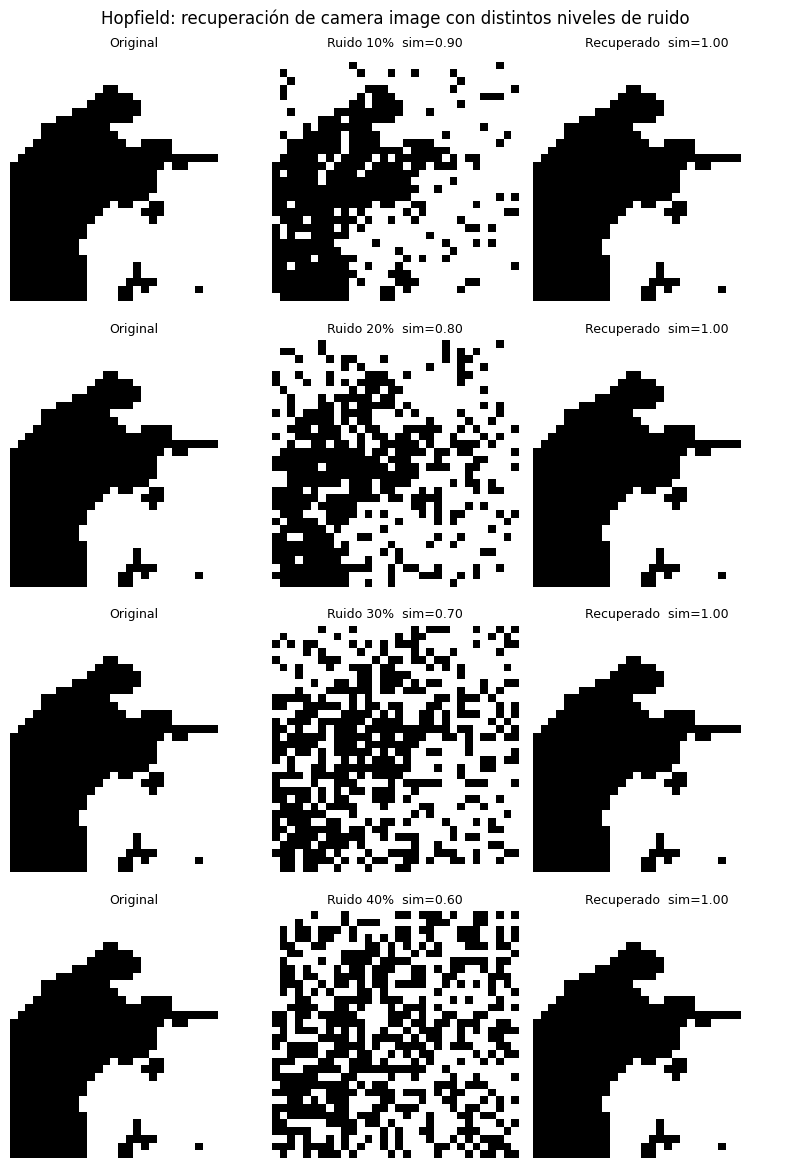

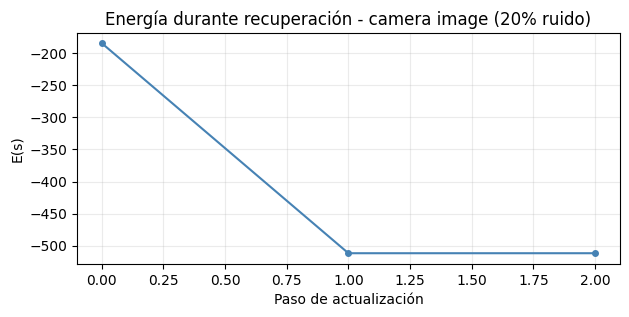

In [8]:
from skimage import data as skdata
from skimage.transform import resize as sk_resize

# Imagen original tal como muestra el enunciado
img_cam = skdata.camera()   # imagen 512x512 en escala de grises

plt.figure(figsize=(4, 4))
plt.imshow(img_cam, cmap='gray')
plt.title('Imagen original')
plt.axis('off')
plt.show()

# Reducimos a 32x32 y binarizamos a {-1, +1}
img_small = sk_resize(img_cam, (32, 32), anti_aliasing=True)   # valores en [0, 1]
img_bin   = np.where(img_small > 0.5, 1.0, -1.0)

# Almacenamos como único patrón
patron_cam = imagen_a_vector(img_bin)
W_cam = calcular_pesos([patron_cam])

print(f'N = {patron_cam.shape[0]} neuronas')
print(f'W_cam: {W_cam.shape}, simétrica: {np.allclose(W_cam, W_cam.T)}')

# Recuperación con distintos niveles de ruido
niveles = [0.10, 0.20, 0.30, 0.40]
fig, axes = plt.subplots(len(niveles), 3, figsize=(8, 3 * len(niveles)))

for fila, fr in enumerate(niveles):
    xi_r      = agregar_ruido(patron_cam, fraccion_ruido=fr, seed=42)
    xi_rec, _ = recuperar(W_cam, xi_r, n_iter=30, seed=42)
    sim_in  = similitud(patron_cam, xi_r)
    sim_out = similitud(patron_cam, xi_rec)

    axes[fila, 0].imshow(img_bin, cmap='gray', vmin=-1, vmax=1)
    axes[fila, 0].set_title('Original', fontsize=9)
    axes[fila, 0].axis('off')

    axes[fila, 1].imshow(xi_r.reshape(32, 32), cmap='gray', vmin=-1, vmax=1)
    axes[fila, 1].set_title(f'Ruido {int(fr*100)}%  sim={sim_in:.2f}', fontsize=9)
    axes[fila, 1].axis('off')

    axes[fila, 2].imshow(xi_rec.reshape(32, 32), cmap='gray', vmin=-1, vmax=1)
    axes[fila, 2].set_title(f'Recuperado  sim={sim_out:.2f}', fontsize=9)
    axes[fila, 2].axis('off')

plt.suptitle('Hopfield: recuperación de camera image con distintos niveles de ruido')
plt.tight_layout()
plt.show()

# Evolución de la energía (ruido 20%)
xi_r20 = agregar_ruido(patron_cam, fraccion_ruido=0.2, seed=42)
_, hist_e_cam = recuperar(W_cam, xi_r20, n_iter=30, seed=42)

plt.figure(figsize=(7, 3))
plt.plot(hist_e_cam, marker='o', markersize=4, color='steelblue')
plt.xlabel('Paso de actualización')
plt.ylabel('E(s)')
plt.title('Energía durante recuperación - camera image (20% ruido)')
plt.grid(alpha=0.25)
plt.show()

## 8. Preguntas guía

**1. ¿La energía disminuye durante la recuperación?**

Sí, siempre. En la actualización asíncrona, al cambiar el estado de la neurona $i$ al valor
$\text{sign}(h_i)$, el cambio en energía satisface $\Delta E \leq 0$: la red solo puede moverse
hacia mínimos de energía, nunca hacia arriba. Esto garantiza convergencia.

---

**2. ¿La red recupera exactamente la imagen original?**

Depende del nivel de ruido. Con ruido bajo (≤20%) suele recuperar exactamente el patrón.
Con ruido alto puede converger a un estado espurio o a la imagen negada ($-\xi$),
que también es un mínimo de energía. La convergencia a algún mínimo está garantizada,
pero no que ese mínimo sea el patrón original.

---

**3. ¿Qué ocurre si se aumenta el nivel de ruido?**

A medida que sube el ruido, el estado inicial se aleja del patrón original y se acerca a
otros mínimos. Hay un umbral crítico a partir del cual la recuperación falla: la red converge
al mínimo equivocado. Con camera image se observa que a 40% de ruido la similitud de salida
cae notablemente.

---

**4. ¿Qué pasa si se almacenan varias imágenes?**

Los pesos de todos los patrones se suman (regla de Hebb aditiva). Cuando $P \ll 0.14N$
la interferencia es baja y la recuperación funciona bien. Al acercarse a la capacidad máxima,
los patrones se mezclan en la matriz de pesos y la tasa de recuperación cae, como se vio
en el análisis de capacidad de la sección 6.

---

**5. ¿Aparecen estados espurios?**

Sí. Son mínimos locales de energía que no corresponden a ningún patrón almacenado.
El más común es la imagen negada $-\xi^\mu$, que siempre es un mínimo. También
aparecen mezclas de tres patrones con paridad par. Proliferan al superar la capacidad teórica.

---

**6. ¿La recuperación depende del orden en que se actualizan los píxeles?**

Sí en la actualización asíncrona. Órdenes distintos producen trayectorias distintas
y pueden llevar a mínimos locales diferentes. La garantía es que siempre se llega a
algún mínimo, pero cuál depende del orden. Por eso fijamos `seed=42` para reproducibilidad.

---

**7. ¿Qué diferencia hay entre actualización sincrónica y asíncrona?**

- **Asíncrona**: se actualiza una neurona a la vez usando el estado *actual* de las demás.
  La energía no puede aumentar, por lo que la red siempre converge a un punto fijo estable.
- **Sincrónica**: todas las neuronas se actualizan en paralelo con el estado del paso
  *anterior*. Puede generar ciclos de período 2 (oscilaciones) sin llegar a ningún punto
  fijo, por lo que no garantiza convergencia como memoria asociativa.

## Conclusiones

- La regla de Hebb distribuye la información de cada patrón en todos los pesos: la memoria
  es holográfica, no hay neurona dedicada a un patrón concreto.
- La actualización asíncrona garantiza que la energía $E(s) = -\frac{1}{2}\mathbf{s}^T W \mathbf{s}$
  siempre decrece, asegurando la convergencia.
- La red recupera bien patrones con hasta ~30% de ruido cuando el número de patrones
  almacenados está por debajo de la capacidad teórica ($0.14 \cdot N$).
- Superar la capacidad genera estados espurios: mínimos de energía que no corresponden
  a ningún patrón almacenado.
- Aplicado a `data.camera()` (32×32 binarizada, N=1024), el algoritmo funciona igual de bien:
  recupera casi perfectamente con 20% de ruido; a 40% la imagen se degrada visiblemente.
- La actualización sincrónica no garantiza convergencia (puede oscilar), mientras que la
  asíncrona siempre converge aunque el resultado dependa del orden de actualización.